# Introduction to Monte Carlo Methods in Computational Science

## Overview

Monte Carlo methods are a powerful class of numerical techniques that leverage randomness to solve deterministic problems. These methods are widely used in physics, statistics, and computational science for tasks such as numerical integration, optimization, and probabilistic modeling.

In this notebook, we will explore the foundational concepts of Monte Carlo methods, including:

- Random number generation and how probability distributions play a role in sampling.
- Von Neumann rejection sampling, a technique for drawing random numbers from a complex probability distribution.
- The Metropolis algorithm, a Markov Chain Monte Carlo (MCMC) method for generating samples from an arbitrary probability distribution.
- Monte Carlo integration, a method for approximating integrals using random sampling.
- Importance sampling, an optimization technique that improves the efficiency of Monte Carlo integration by reducing variance.

## Why Monte Carlo Methods?

Many integrals and summations in physics and computational science are either high-dimensional or analytically intractable. Monte Carlo methods provide a way to approximate these computations using random sampling. The advantage of Monte Carlo approaches is their ability to handle high-dimensional spaces more effectively than traditional numerical quadrature methods.

## Roadmap

We will first examine how to generate random numbers from different distributions, then introduce the concept of rejection sampling as a method for drawing samples from non-trivial distributions. Building on this, we will explore the Metropolis algorithm, which extends these ideas into an iterative sampling technique. Finally, we will apply these methods to Monte Carlo integration, both with and without importance sampling, to illustrate how we can efficiently estimate integrals that are difficult to evaluate using traditional methods.

# Random Number Generation and Pseudorandom Number Generators

## Random Sequences
Computers are deterministic machines, making it impossible to generate truly random numbers. Instead, they use **pseudorandom number generators (PRNGs)**, which produce sequences of numbers that appear random but are generated by deterministic algorithms.

A sequence of numbers `{r_1, r_2, ... r_n}` is considered **random** if:
- There are no correlations between the numbers.
- The sequence follows a probability distribution $ P(r) $.
- It satisfies properties such as **unpredictability, independence, and absence of patterns**.

For example, a **uniformly distributed** sequence means that all numbers have an equal probability of appearing, represented as $ P(r) = 1 $ for a standard uniform distribution in $ [0,1] $.

## Pseudorandom Number Generators (PRNGs)
Since true randomness is not achievable in computers, PRNGs generate sequences using deterministic mathematical formulas. One common approach is the **Linear Congruential Generator (LCG)**, which follows the recurrence relation:

$$
r_{i+1} = (a r_i + c) \mod M
$$

where:
- $ r_1 $ is the **seed**, which initializes the sequence,
- $ a $, $ c $, and $ M $ are carefully chosen constants,
- The sequence has a periodicity of at most $ M $.

### Example of an LCG
Choosing $ c = 1 $, $ a = 4 $, $ M = 9 $, and $ r_1 = 3 $, the generated sequence cycles every 9 steps.

$$
\begin{aligned}
r_1 &= 3, \\
r_2 &= (4 \times 3 + 1) \mod 9 = 4, \\
r_3 &= (4 \times 4 + 1) \mod 9 = 8, \\
r_4 &= (4 \times 8 + 1) \mod 9 = 6, \\
&\quad 7, 2, 0, 1, 5, 3, \dots
\end{aligned}
$$

The period of an LCG depends on the choice of constants and follows conditions from the **Hull-Dobell Theorem**. The theorem states if and only if 3 conditions are met, will the period of the LCG be equal to $M$:
1. $m$ and $c$ are coprime
2. $a-1$ is divisible by all the prime factors of $M$
3. $a-1$ is divisible by 4 if m is divisible by 4

In [ ]:
def factor(n):
    # FACTOR returns the prime factors of a number n
    factors = {1}
    #even numbers
    while n % 2 == 0:
        factors.add(2)
        n //= 2
    i = 3
    # odd numbers
    while i**2 <= n:
        while n % i == 0:
            factors.add(i)
            n //= i
        i += 2
    if n > 2:
        factors.add(n)
    return factors      
factor(6537169170218971)

In [ ]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt

N = 100000
r = np.zeros(N+1)
M = 6537169170218971
a = 52361276312121
c = 83872723
seed = 12391.
r[0] = seed
for i in range(1, N+1):
    r[i] = (a*r[i-1]+c) % M

r1 = np.zeros(N//2)
r2 = np.zeros(N//2)
for i in range(0,N,2):
    r1[i//2] = float(r[i])/float(M)
    r2[i//2] = float(r[i+1])/float(M)

plt.plot(r1, r2, 'o')

In [ ]:
normalized_r = r/float(M)
# histogram
plt.figure()
plt.hist(normalized_r, bins=100, density=True)
plt.show()

## Limitations of Simple PRNGs
- **Short cycles:** Poor choices of parameters can result in sequences repeating too quickly.
- **Correlations:** Some PRNGs, like the infamous **RANDU**, were flawed and led to incorrect scientific results.
- **Determinism:** Knowing one number can reveal the entire sequence.

To improve randomness, modern PRNGs use more sophisticated algorithms.

In [ ]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt

N = 100000
r = np.zeros(N+1)
# This the infamous RANDU
M = 2**31
a = 65539

seed = 121.
r[0] = seed
for i in range(1, N+1):
    r[i] = (a*r[i-1]) % M

r1 = np.zeros(N//2)
r2 = np.zeros(N//2)
for i in range(0,N,2):
    r1[i//2] = float(r[i])/float(M)
    r2[i//2] = float(r[i+1])/float(M)

plt.plot(r1, r2, 'o')


In [ ]:
normalized_r = r/float(M)
# histogram
plt.figure()
plt.hist(normalized_r, bins=100, density=True)
plt.show()

In [ ]:
%matplotlib inline
r1 = np.zeros(int(N/3))
r2 = np.zeros(int(N/3))
r3 = np.zeros(int(N/3))

for i in range(0,N-1,3):
    r1[int(i/3)] = r[i]/float(M)
    r2[int(i/3)] = r[i+1]/float(M)
    r3[int(i/3)] = r[i+2]/float(M)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.view_init(elev=20., azim=60)

ax.scatter(r1,r2,r3,marker="o"); 
plt.show()


## The Mersenne Twister
A widely used PRNG in scientific computing is the **Mersenne Twister (MT19937)**. It has several advantages:
- **Extremely long period** ($ 2^{19937}-1 $), preventing short cycles.
- **Good statistical properties**, passing most randomness tests.
- **Efficient generation**, making it ideal for Monte Carlo simulations.

Python’s `random` module and NumPy’s `numpy.random` module use variations of the Mersenne Twister, making it the standard for many Monte Carlo applications.


## Key Desirable Properties for PRNGs
For Monte Carlo simulations, an ideal PRNG should be:
- **Efficient**: Able to generate many numbers quickly.
- **Long-period**: Avoiding early repetition.
- **Repeatable**: For debugging purposes.
- **Resumable**: Allowing simulations to pick up where they left off.
- **Splittable**: Allowing independent parallel random streams.

# Non-uniform random distributions

In the previous section we learned how to generate random deviates with a uniform probability distribution in an interval $[a,b]$. This distributioon is normalized, so that $$\int _a^b {P(x)dx}=1.$$ Hence, $P(x)=1/(b-a)$.

Now, suppose that we generate a sequence $\{x_i\}$ and we take some function of it to generate $\{y(x_i)\}=\{y_i\}$. This new sequence is going to be distributed according to some probability density $P(y)$, such that $$P(y)dy=P(x)dx$$ or $$P(y)=P(x)\frac{dx}{dy}.$$

If we want to generate a desired normalized distribution $P(y)$, we need to solve the differential equation: 
$$\frac{dx}{dy}=P(y).$$ 
But the solution of this is $$x=\int _0^y {P(y')dy'}=F(y),$$ where $F(y)$ is known as the cumulative distribution function (CDF).

Therefore, 
$$y(x)=F^{-1}(x),$$ 
where $F^{-1}$ is the inverse of $F$.

### Exponential distribution

As an example, let us take $P(x)$ representing a uniform distribution in the interval $[0,1]$. We want to sample from
$$P(y)=\frac{dx}{dy}=e^{-y},$$  

To figure out the relevant transformation, we compute the CDF 
$$x=F(y)=\int _0^y {e^{-y'}dy'}=1-e^{-y}.$$
Solving for $y$ in terms of $x$, we have 
$$y=F^{-1}(x)=-\ln{(1-x)}.$$
This distribution occurs frequently in real problems such as the radioactive decay of nuclei. You can also see that the quantity $y/\lambda$ has the
distribution $\lambda e^{-\lambda y}$.


In [ ]:
%matplotlib inline 
import numpy as np
from matplotlib import pyplot as plt

N = 100000
x = np.random.random(N)

lam = 0.3
#Transformation equation
y = -np.log(1-x)/lam

binwidth=lam*5
plt.hist(y,bins=np.arange(0.,100.,binwidth),density=True)
plt.plot(np.arange(0.,100.,binwidth),lam*np.exp(-lam*np.arange(0.,100.,binwidth)))

### Gaussian Draws
You can get Gaussian random variables by the so-called Box-Muller transform. We'll demonstrate that it *works*, but for a thorough introduction read here: [Box-Muller Wikipedia](https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform).

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

N=10000

def box_muller(u1, u2):
    z0 = np.sqrt(-2*np.log(u1))*np.cos(2*np.pi*u2)
    z1 = np.sqrt(-2*np.log(u1))*np.sin(2*np.pi*u2)
    return z0, z1

u1, u2 = np.random.rand(N), np.random.rand(N)

z0, z1 = box_muller(u1, u2)

fig, axs = plt.subplots(1,2, figsize=(12,5))

axs[0].hist(u1,bins=30,density=True)
axs[0].set_title('Uniform Distribution')
axs[0].set_xlim([0,1])

axs[1].hist(z0, bins=30, density=True, alpha=0.4, color='pink', edgecolor='black', label='z0')
axs[1].hist(z1, bins=30, density=True, alpha=0.4, color='lightgreen', edgecolor='black', label='z1')
axs[1].set_title('Normal Distribution')
axs[1].legend()

plt.tight_layout()
plt.show()

# von Neumann rejection sampling

Rejection sampling was invented by von Neumann in 1951. It is a simple and general method for generating arbitrary distributions. The idea is to sample uniformly from a region known to enclose the distribution of interest, and to reject any samples that lie outside the region.

To do rejection sampling, draw a plot with your probability distribution, and on the same graph, plot another curve $f(x)$ which has finite area and lies everywhere above your original distribution, that is for some constant $C$, $$P(x)\le C f(x).$$ We will call $f(x)$ the “comparison function”. You should be able to draw numbers from the comparison function $f(x)$. Generate a random number $x_i$ from $f(x)$ and a number $u$ form an uniform distribution. If $$u\le \frac{P(x)}{Cf(x)},$$ we accept $x_i$ as a valid sample; otherwise, we reject it and draw new random numbers.  The fraction of points accepted/rejected will depend on the ratio between the two areas. The closer the comparison function $f(x)$ resembles $P(x)$, the more points will be accepted. Ideally, for $P(x)=f(x)$, all the points will be accepted, and none rejected. However, in practice, this is not always possible, but we can try to pick $f(x)$ such that we minimize the fraction of rejected points.

No doubt you have seen rejection techniques in a common homework problem: computing $\pi$ by drawing random points in a square between $0$ and $1$ and counting how many were inside a circle. The circle is the region enclosing the distribution of interest, the uniform density on the circle, and the square is the region from which you can easily draw, as shown above. By rejection sampling, you computed the volume of the circle relative to the volume of the square. That ratio is $\pi/4$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def P(x):
    """Target distribution: Example - a custom probability density function (PDF)."""
    return 0.3 * np.exp(-0.2 * x**2) + 0.7 * np.exp(-0.5 * (x - 8)**2)

def f(x):
    """Proposal distribution: A Gaussian with mean 2 and standard deviation 2."""
    return np.exp(-0.5 * ((x - 2) / 6) ** 2)

# Constant C such that P(x) <= C * f(x) for all x
C = 0.5

def rejection_sampling(num_samples):
    """Von Neumann rejection sampling algorithm."""
    samples = []
    inter = 0
    while len(samples) < num_samples:
        # Sample x from proposal distribution f(x)
        x_candidate = np.random.normal(loc=2, scale=3)  # Sample from normal dist matching f(x)
        u = np.random.uniform(0, 1)  # Uniform random number in [0,1]
        inter=inter+1
        # Acceptance criterion
        if u < P(x_candidate) / (C * f(x_candidate)):
            samples.append(x_candidate)
        
    return np.array(samples), inter

# Generate samples
num_samples = 10000
samples, inter = rejection_sampling(num_samples)
print(inter)
# Plot results
x_vals = np.linspace(-5, 7, 1000)
plt.figure(figsize=(8, 5))
plt.hist(samples, bins=50, density=True, alpha=0.6, label='Sampled Distribution')
plt.plot(x_vals, P(x_vals), label='Target Distribution P(x)', linewidth=2)
plt.plot(x_vals, C * f(x_vals), linestyle='dashed', label='Scaled Proposal C*f(x)', linewidth=2)
plt.legend()
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Von Neumann Rejection Sampling')
plt.show()

## Problem: Estimating $\pi$ with Rejection Sampling?
The classic problem of estimating $\pi$ by generating pairs of numbers in the $[0,1]$ 2D range and rejecting those points falling outside the first quadrant of a unit circle is an example of rejection sampling.

In [ ]:
import numpy as np
N=10000
x = np.random.random(N)
y = np.random.random(N)
sample = 0
for k in range(len(x)):
    r = x[k]**2+y[k]**2
    if r<1:
        sample = sample+1
p = sample/N
print(4*p)

# Random walk methods: the Metropolis algorithm

Suppose that we want to generate random variables according to an arbitrary probability density $P(x)$. The Metropolis algorithm produces a “random walk” of points $\{x_i\}$ whose asymptotic probability approaches $P(x)$ after a large number of steps. The random walk is defined by a “transition probability” $w(x_i \rightarrow x_j)$ for one value $x_i$ to another $x_j$ in order that the distribution of points $x_0$, $x_1$, $x_2$, ... converges to $P(x)$. In can be shown that it is sufficient (but not necessary) to satisfy the “detailed balance” condition 
$$p(x_i)w(x_i \rightarrow x_j) = p(x_j)w(x_j \rightarrow x_i).$$ 
This relation dos not specify $w(x_i \rightarrow x_j)$ uniquely. A simple choice is 
$$w(x_i \rightarrow x_j)=\min{\left[ 1,\frac{P(x_j)}{P(x_i)} \right] }.$$ 
This choice can be described by the following steps. Suppose that the “random walker” is a position $x_n$. To generate $x_{n+1}$ we

1.  choose a trial position $x_t=x_n+\delta _n$ , where the $\delta _n$ is a random number in the interval $[-\delta ,\delta]$.

2.  Calculate $w=P(x_t)/P(x_n)$.

3.  Draw a uniform random number $u$

5.  If $u \leq w$, accept the change and let $x_{n+1} = x_t$.

7.  If the trial change is not accepted, the let $x_{n+1}=x_n$. Try again

It is necessary to sample a number of points of the random walk before the asymptotic probability $P(x)$ is attained. How do we choose the “step size” $\delta$? If $\delta$ is too large, only a small fraction of changes will be accepted and the sampling will be inefficient. If $\delta$ is too small, a large number will be accepted, but it would take too long to sample $P(x)$ over the whole interval of interest. Ideally, we want at least 1/3-1/2 of the trial steps to be accepted. We also want to choose $x_0$ such that the distribution $\{x_i\}$ converges to $P(x)$ as quickly as possible. An obvious choice is to begin the random walk at the point where $P(x)$ is maximum.

## The Gaussian distribution
Let's use the Metropolis algorithm to generate a Gaussian distribution 
$$P(x)=A \exp{(-x^2/2\sigma ^2)}.$$ 
Is the numerical value of the normalization constant $A$ relevant? Can we determine a reasonable choice of $\delta$ for a given $\sigma$? (choose $x_0 = 0$.)
    

In [ ]:
def metropolis(xold):
    fluctuation = np.random.random() 
    xtrial = xold + (2*fluctuation-1)*delta
    weight = np.exp(-(xtrial**2-xold**2)/(2*sigma2))

    if weight >= 1:
        return xtrial
    else:
        r = np.random.random()
        if r < weight:
            return xtrial
        else:
            return xold

In [ ]:
N = 100000

x = np.zeros(N)
delta = 3.
sigma = 20. 
sigma2 = sigma**2
#initial sample of points
xwalker = 20. 
Nwarmup = 5
for i in range(Nwarmup):
    xwalker = metropolis(xwalker)

subsample = True

x[0] = xwalker
for i in range(1,N):
    xold = x[i-1]
    if not subsample:
        xnew = metropolis(xold)
    else:
        for j in range(10):
            xnew = metropolis(xold)
            xold = xnew
    x[i] = xnew

binwidth = sigma/10
bins = np.arange(-50,50,binwidth)
plt.hist(x, bins=bins, density=True)

plt.rcParams['figure.dpi'] = 50
norm = 1./(sigma*np.sqrt(2*np.pi))
plt.plot(bins, norm*np.exp(-bins**2/(2*sigma2)), color='red')

# In-Class Activity: Metropolis Sampling of the Quantum Harmonic Oscillator Ground State

## Background

In the lecture we used the Metropolis algorithm to sample from a Gaussian distribution. Here we put it to work on a physically motivated target — the ground-state probability density of the 1D quantum harmonic oscillator (QHO):

$$\psi_0(x) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4} e^{-m\omega x^2 / 2\hbar}$$

The corresponding probability density is $P(x) = |\psi_0(x)|^2$. In natural units where $\hbar = m = \omega = 1$ this simplifies to:

$$P(x) = \frac{1}{\sqrt{\pi}}\, e^{-x^2}$$

### Why is this a good test case?

- The distribution is analytically known, so you can verify your sampler directly.
- It forces you to confront the two most important practical issues in any Metropolis simulation: **step size tuning** and **burn-in**.
- Physical observables such as $\langle x^2 \rangle$ have exact quantum mechanical values you can check against.

### Key reminder from the lecture

The Metropolis acceptance ratio is
$$w = \frac{P(x_\text{trial})}{P(x_n)}.$$
The normalization constant in $P(x)$ cancels in this ratio — it is **completely irrelevant**. This is one of the algorithm's great strengths: you only ever need an *unnormalized* target.

## Part 1: Implement and Tune the Sampler


Complete the Metropolis sampler below. A few things to note before you start:

- Work with `log_P` rather than `P` directly. In log-space the acceptance ratio becomes
$$w = \exp\!\bigl[\log P(x_\text{trial}) - \log P(x_n)\bigr]$$
This is numerically safer and is standard practice in any serious MCMC code — for high-dimensional problems $P(x)$ itself would underflow to zero.

- **Do not** use `np.random.normal` to generate the samples. The Metropolis walker generates them for you; that is the whole point.

- Run the sampler with $\delta = 0.1$, $1.0$, and $5.0$ and print the acceptance rate for each.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def log_P(x):
    """Log of the unnormalized target distribution P(x) ∝ exp(-x²).
    The normalization constant 1/sqrt(π) is dropped — it cancels in the ratio."""
    return -x**2


def metropolis_qho(n_steps, delta, x0=0.0):
    """
    Run the Metropolis algorithm to sample from P(x) ∝ exp(-x²).

    Parameters
    ----------
    n_steps : int
        Total number of Metropolis steps.
    delta : float
        Half-width of the uniform proposal distribution [-delta, delta].
    x0 : float
        Starting position of the walker.

    Returns
    -------
    samples     : np.ndarray, shape (n_steps,)
    accept_rate : float
    """
    samples = np.zeros(n_steps)
    x = x0
    n_accepted = 0

    for i in range(n_steps):
        # --- YOUR CODE HERE ---
        # Step 1: Propose  x_trial = x + uniform draw from [-delta, delta]

        # Step 2: Compute acceptance ratio w = exp(log_P(x_trial) - log_P(x))

        # Step 3: Accept with probability min(1, w)
        #         If accepted: x = x_trial, increment n_accepted
        #         If rejected: x stays the same

        # Step 4: Store current x
        samples[i] = x
        # ----------------------

    return samples, n_accepted / n_steps


# Test with three different step sizes
for delta in [0.1, 1.0, 5.0]:
    samples, rate = metropolis_qho(n_steps=100_000, delta=delta, x0=0.0)
    print(f"δ = {delta:.1f}  →  acceptance rate = {rate:.3f}")

What acceptance rates do you get for $\delta = 0.1$, $1.0$, and $5.0$?

The lecture states that ideally **1/3–1/2 of trial steps should be accepted**. Which $\delta$ comes closest to this target? Explain physically why both extremes (too small and too large a step size) lead to inefficient sampling, even if the acceptance rate looks superficially reasonable for $\delta = 0.1$.

*Hint: think about how far the walker actually explores configuration space per unit time in each case.*

## Part 2: Burn-in and the Trace Plot

A Metropolis chain started far from the distribution's bulk takes time to "forget" its initial condition. This transient phase is called the **burn-in** (or **thermalization**). Samples collected during burn-in are biased and must be discarded before computing any observable.

Run the sampler starting at $x_0 = 10$ (far from the mode at $x = 0$) and use a trace plot to diagnose how long the burn-in lasts

In [ ]:
samples_far, _ = metropolis_qho(n_steps=10_000, delta=1.0, x0=10.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Left panel: trace plot ---
axes[0].plot(samples_far[:500], lw=0.8)
axes[0].axhline(0, color='red', ls='--', lw=1.5, label='mode')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('x')
axes[0].set_title('Trace plot (first 500 steps)')
axes[0].legend()

# --- Right panel: histogram before and after burn-in removal ---
n_burnin = 200   # <-- adjust this and observe the effect

x_vals = np.linspace(-4, 4, 400)
P_exact = np.exp(-x_vals**2) / np.sqrt(np.pi)

axes[1].hist(samples_far,            bins=60, density=True, alpha=0.45, label='all samples')
axes[1].hist(samples_far[n_burnin:], bins=60, density=True, alpha=0.45,
             label=f'after {n_burnin}-step burn-in')
axes[1].plot(x_vals, P_exact, 'k-', lw=2, label=r'$P(x)$ exact')
axes[1].set_xlabel('x')
axes[1].set_title('Effect of burn-in removal')
axes[1].legend()

plt.tight_layout()
plt.show()

## Part 3: Computing a Physical Observable
The power of MCMC is that once you have samples distributed according to $P(x)$, expectation values of any observable $O(x)$ are just sample means:

$$\langle O \rangle = \int O(x)\, P(x)\, dx \approx \frac{1}{N} \sum_{i=1}^{N} O(x_i)$$

For the QHO ground state in natural units, the zero-point variance has the exact value:

$$\langle x^2 \rangle = \frac{1}{2}$$

Estimate this from your Metropolis samples.

# Monte Carlo integration

Imagine that we want to measure the area of a pond with arbitrary shape. Suppose that this pond is in the middle of a field with known area $A$. If we throw $N$ stones randomly, such that they land within the boundaries of the field, and we count the number of stones that fall in the pond $N_{in}$, the area of the pond will be approximately proportional to the fraction of stones that make a splash, multiplied by$A$: 
$$A_{pond}=\frac{N_{in}}{N}A.$$ 
This simple procedure is an example of the “Monte Carlo” method.

## Simple Monte Carlo integration

More generaly, imagine a rectangle of height $H$ in the integration interval $[a,b]$, such that the function $f(x)$ is within its boundaries. Compute $n$ pairs of random numbers $(x_i,y_i)$ such that they are uniformly distributed inside this rectangle. The fraction of points that fall within the area contained below $f(x)$, <span>*i.e.*</span>, that satisfy $y_i \leq f(x_i)$ is an estimate of the ratio of the integral of $f(x)$ and the area of the rectangle. Hence, the estimate of the integral will be given by:
$$\int _a^b{f(x)dx} \simeq I(N) = \frac{N_{in}}{N}H(b-a).$$

Another Monte Carlo procedure is based on the definition:
$$\langle f \rangle=\frac{1}{(b-a)} \int _a^b{f(x)dx}.$$ 
In order to determine this average, we sample the value of $f(x)$:
$$\langle f \rangle \simeq \frac{1}{N}\sum_{i=1}^{N}f(x_i),$$ 
where the $N$ values $x_i$ are distributed uniformly in the interval $[a,b]$. The
integral will be given by $$I(N)=(b-a) \langle f \rangle.$$

In [ ]:
import numpy as np
#Simple integration of x^2 from 0 to 1, b-a = 1
samples = np.random.random(10000)
x2 = samples**2
my_integral = np.mean(x2) # this is the integral of x^2 from 0 to 1
print(my_integral)

### Example: One dimensional integration 
Consider the integral: $$\int_{0}^{1}4\sqrt{1-x^2}\,dx$$ 


In [ ]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot

x = np.arange(0,1,0.02)
pyplot.plot(x, 4*np.sqrt(1-x**2))

In [ ]:
# Hit and miss Monte Carlo integration
ngroups = 16

I = np.zeros(ngroups)
N = np.zeros(ngroups)
E = np.zeros(ngroups)
#number of points
n0 = 100 
for i in range(ngroups):
    #for a number of points
    N[i] = n0
    #draw numbers??
    x = np.random.random(n0)
    y = np.random.random(n0)
    I[i] = 0.
    Nin = 0
    for j in range(n0):
        if(y[j]< np.sqrt(1-x[j]**2)):
            Nin += 1
            
    I[i] = 4.*float(Nin)/float(n0)
    E[i] = abs(I[i]-np.pi)
    print (n0,Nin,I[i],E[i])
    n0 *= 2
    
            
pyplot.plot(N,E,ls='-',c='red',lw=3);
pyplot.plot(N,1/np.sqrt(N),ls='-',c='blue',lw=3);
pyplot.xlabel('number of points')
pyplot.ylabel('error')
pyplot.xscale('log')
pyplot.yscale('log')

## Monte Carlo Error Analysis

### Where the error comes from

The mean-value MC estimate of an integral is:

$$I(N) = (b-a)\,\frac{1}{N}\sum_{i=1}^{N} f(x_i), \qquad x_i \sim \text{Uniform}(a,b)$$

This is just a sample mean of $f(x)$ over randomly drawn points. The true integral is
$I = (b-a)\,\langle f \rangle$, so the question "how accurate is $I(N)$?" is exactly
the question "how well does a sample mean estimate the true mean?"

The answer is given by the **Central Limit Theorem**: as $N$ grows, the distribution
of $I(N)$ across many independent runs becomes Gaussian, centered on the true value $I$,
with a width (standard error) of:

$$\delta I = \frac{(b-a)\,\sigma_f}{\sqrt{N}}$$

where $\sigma_f$ is the **standard deviation of the integrand** over the sampling region:

$$\sigma_f^2 = \langle f^2 \rangle - \langle f \rangle^2$$

Three things to notice:

1. **Error $\propto 1/\sqrt{N}$.** Halving the error costs 4× the samples. This is the fundamental MC convergence rate.
2. **Error $\propto \sigma_f$.** If the integrand is nearly flat, $\sigma_f$ is small and you need fewer samples. This is the motivation for variance reduction methods.
3. **You don't need to run multiple experiments.** You can estimate $\sigma_f$ from your single run:

$$\hat{\sigma}_f^2 = \langle f^2 \rangle - \langle f \rangle^2$$

computed from the same $N$ samples, giving a practical error bar $\delta I \approx (b-a)\,\hat{\sigma}_f/\sqrt{N}$.

In practice you report: $I \approx I(N) \pm \delta I$. You can tighten this either by
increasing $N$ or by reducing $\sigma_f$.

Increasing $N$ is expensive: the $1/\sqrt{N}$ scaling means you need $100\times$ more
samples just to gain one decimal place of accuracy. Reducing $\sigma_f$ is far more
powerful — if you could somehow make the integrand perfectly flat, $\sigma_f = 0$ and
you'd get the exact answer with a single sample.

This suggests a strategy: instead of sampling $x$ uniformly, sample more points from
regions where $f(x)$ is large (and therefore contributes most to the integral), and
fewer from regions where $f(x)$ is small. Done correctly, the effective variance of
what you're averaging is reduced without introducing any bias into the estimate.

This is the idea behind **importance sampling**, which we turn to below.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ── Estimate π using MC, with error bars ──────────────────────────────────────
# Integral of 4*sqrt(1-x^2) from 0 to 1 = π.
# f(x) = 4*sqrt(1 - x^2), sampled uniformly on [0,1], so (b-a)=1.

def f(x):
    return 4 * np.sqrt(1 - x**2)

N_values = np.logspace(1, 6, 40, dtype=int)

estimates = []
error_bars = []

for N in N_values:
    x = rng.uniform(0, 1, N)
    fx = f(x)
    I_hat = np.mean(fx)                       # integral estimate
    sigma_f = np.std(fx, ddof=1)              # sample std dev of integrand
    eps = sigma_f / np.sqrt(N)                # standard error (b-a = 1)
    estimates.append(I_hat)
    error_bars.append(eps)

estimates = np.array(estimates)
error_bars = np.array(error_bars)
true_error = np.abs(estimates - np.pi)

# ── Plot: true error vs predicted error bar ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.loglog(N_values, true_error, 'o', ms=4, alpha=0.7, label='|I(N) - π|  (true error)')
ax.loglog(N_values, error_bars, '-', lw=2, label=r'$\hat{\varepsilon}_N = \hat{\sigma}_f/\sqrt{N}$  (predicted)')
ax.loglog(N_values, 1/np.sqrt(N_values), 'k--', alpha=0.4, label=r'$1/\sqrt{N}$ reference')
ax.set_xlabel('N (samples)')
ax.set_ylabel('Error')
ax.set_title('True error vs. predicted error bar')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

# ── Plot: sampling distribution of I(N) at fixed N ────────────────────────────
# Run 1000 independent estimates at N=500, show the distribution
N_fixed = 500
n_trials = 1000
trial_estimates = np.array([np.mean(f(rng.uniform(0, 1, N_fixed))) for _ in range(n_trials)])

# Predicted Gaussian from CLT
x_grid = np.linspace(trial_estimates.min(), trial_estimates.max(), 300)
sigma_predicted = np.std(f(rng.uniform(0, 1, 100_000))) / np.sqrt(N_fixed)
from scipy.stats import norm
pdf_predicted = norm.pdf(x_grid, loc=np.pi, scale=sigma_predicted)

ax = axes[1]
ax.hist(trial_estimates, bins=40, density=True, alpha=0.6, label=f'1000 estimates (N={N_fixed})')
ax.plot(x_grid, pdf_predicted, 'r-', lw=2.5,
        label=f'CLT prediction: σ={sigma_predicted:.4f}')
ax.axvline(np.pi, color='k', lw=2, ls='--', label='π (true value)')
ax.set_xlabel('Integral estimate I(N)')
ax.set_ylabel('Density')
ax.set_title(f'Sampling distribution of MC estimator  (N={N_fixed})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Empirical std of estimates:  {np.std(trial_estimates):.5f}")
print(f"CLT-predicted std:           {sigma_predicted:.5f}")


## Variance reduction

If the function being integrated does not fluctuate too much in the interval of integration, and does not differ much from the average value, then the standard Monte Carlo mean-value method should work well with a reasonable number of points. Otherwise, we will find that the variance is very large, meaning that some points will make small contributions, while others will make large contributions to the integral. If this is the case, the algorithm will be very inefficient. The method can be improved by splitting the function $f(x)$ in two $f(x)=f_1(x)+f_2(x)$, such that the integral of $f_1(x)$ is known, and $f_2(x)$ as a small variance. The “variance reduction” technique, consists then in evaluating the integral of $f_2(x)$ to obtain:
$$\int _a^b{f(x)dx}=\int _a^b {f_1(x)dx} + \int _a^b{f_2(x)dx} = \int_a^b{f_1(x)dx}+J.$$

## Importance Sampling

Imagine that we want to sample the function $f(x)=e^{-x^2}$ in the interval $[0,1]$. It is evident that most of our points will fall in the region where the value of $f(x)$ is very small, and therefore we will need a large number of values to achieve a decent accuracy. A way to improve the measurement by reducing the variance is obtained by “importance sampling”. As the name says, the idea is to sample the regions with larger contributions to the integral. For this goal, we introduce a probability distribution $P(x)$ normalized in the interval of integration $$\int _a^b{P(x)dx} = 1.$$ Then, we can rewrite the integral of $f(x)$ as 
$$I=\int _a^b{\frac{f(x)}{P(x)}P(x)dx}$$ 
We can evaluate this integral, by sampling according to the probability distribution $P(x)$ and evaluating the sum
$$I(N)=\frac{1}{N} \sum_{i=1}^N \frac{f(x_i)}{P(x_i)}.$$ 
Note that for the uniform case $P(x)=1/(b-a)$, the expression reduces to the simple Monte Carlo integral.

We are free to choose $P(x)$ now. We wish to do it in a way to reduce and minimize the variance of the integrand $f(x)/P(x)$. The way to to this is picking a $P(x)$ that mimics $f(x)$ where $f(x)$ is large. If we are able to determine an appropiate $P(x)$, the integrand will be slowly
varying, and hence the variance will be reduced. Another consideration is that the generation of points according to the distribution $P(x)$
should be a simple task. As an example, let us consider again the integral 
$$I=\int{e^{-x^2}dx}.$$ 
A reasonable choice for a weigh function is $P(x)=Ae^{-x^2}$, where $A$ is a normalization constant.

Notice that for $P(x)=f(x)$ the variance is zero! This is known as the zero variance property. There is a catch, though: The probability function $P(x)$ needs to be normalized, implying that in reality, $P(x)=f(x)/\int f(x)dx$, which assumes that we know in advance precisely the integral that we are trying to calculate!

In [1]:
import numpy as np
import scipy.integrate as sci
import matplotlib.pyplot as plt
def f(x):
    return np.exp(-x**2)

a, b = -20, 20
# use the trapezoid rule
def trapezoidal_rule(f, a, b, n=1000):
    x = np.linspace(a, b, n)
    y = f(x)
    dx = (b-a) / (n-1)
    return sci.trapezoid(y, dx = dx)

for n in [2**k for k in range(1,10)]:
    print(trapezoidal_rule(f, a, b, n=n))
# See how it does
trape = trapezoidal_rule(f, a, b, n=1000000)
print(trape)

7.660678386856023e-173
1.3304291714120003e-18
0.0032563484443036326
0.9014049490199494
1.7630102605685372
1.7724538508229375
1.7724538509055172
1.7724538509055163
1.772453850905516
1.772453850905516


In [2]:
truthbyn = np.sqrt(np.pi)
print(truthbyn)

1.7724538509055159


In [3]:
def monte_carlo_uniform(f,a,b,n=1000):
    samples = np.random.uniform(a,b,n)
    avg_value = np.mean(f(samples))
    return (b-a)*avg_value

def importance_sampling(f, n=1000):
    samples = np.random.normal(loc=0,scale=1,size=n)
    weights = f(samples) / (1/np.sqrt(2*np.pi)*np.exp(-samples**2/2))
    return np.mean(weights)
    
# trap_result = trapzoidal_rule(f, a, b)
importance_result = importance_sampling(f, n=1000000)
monte_carlo_result = monte_carlo_uniform(f, a, b, n=1000000)

print('Trapezoid:', trape)
print('Importance sampling:', importance_result)
print('Monte Carlo:', monte_carlo_result)

Trapezoid: 1.772453850905516
Importance sampling: 1.7713063221064709
Monte Carlo: 1.7802438814593369


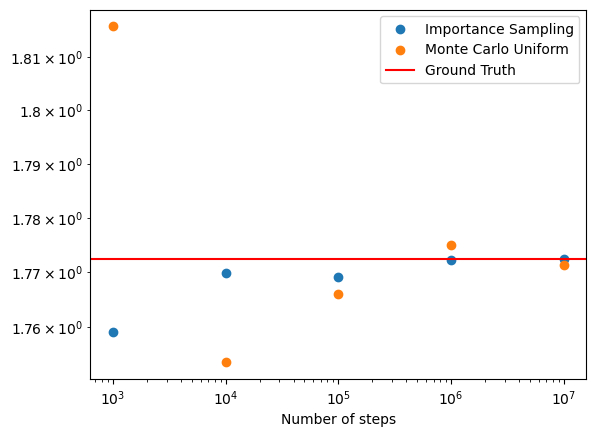

In [5]:
imp, mc = [], []
ns = [10**k for k in range(3,8)]
for n in ns:
    imp.append(importance_sampling(f, n))
    mc.append(monte_carlo_uniform(f, a, b, n))

plt.scatter(ns, imp, label='Importance Sampling')
plt.scatter(ns, mc, label='Monte Carlo Uniform')
plt.axhline(truthbyn, color='red', label='Ground Truth')
plt.xlabel('Number of steps')
plt.ylabel('')
plt.legend()
plt.xscale('log')
plt.yscale('log')


## High-Dimensional Integration and Importance Sampling

### The curse of dimensionality

Traditional quadrature on a $d$-dimensional grid with $n$ points per axis
requires $n^d$ total evaluations. For $d = 4$ and $n = 100$, that is $10^8$
evaluations. For $d = 10$, it is $10^{20}$ — completely intractable. Monte
Carlo integration sidesteps this: its error scales as $1/\sqrt{N}$
*regardless of dimension*, making it the method of choice for
high-dimensional integrals.

### Importance sampling

Plain Monte Carlo over a large volume wastes samples in regions where the
integrand is negligible. **Importance sampling** concentrates samples where
$f(\mathbf{k})$ is large, reducing variance without changing the estimate's
expected value. Given a normalized proposal density $p(\mathbf{k})$:

$$
\int f(\mathbf{k})\, d^d k 
= \int \frac{f(\mathbf{k})}{p(\mathbf{k})}\, p(\mathbf{k})\, d^d k
\approx \frac{1}{N}\sum_{i=1}^N \frac{f(\mathbf{k}_i)}{p(\mathbf{k}_i)},
\quad \mathbf{k}_i \sim p
$$

The estimator is unbiased for *any* $p > 0$ where $f \neq 0$, but its
variance is minimized when $p \propto |f|$ — i.e., when the proposal
*matches the shape* of the integrand.

### A 4D example with a natural proposal

Consider the integral:

$$
I = \int d^4k\; \frac{e^{-|\mathbf{k}|^2/2}}{1 + |\mathbf{k}|^4}
$$

The integrand has a Gaussian envelope that decays rapidly away from the
origin. The natural proposal is the isotropic Gaussian
$p(\mathbf{k}) = (2\pi)^{-2} e^{-|\mathbf{k}|^2/2}$,
which matches the envelope exactly. The importance weights reduce to:

$$
\frac{f(\mathbf{k})}{p(\mathbf{k})} = \frac{(2\pi)^2}{1 + |\mathbf{k}|^4}
$$

These weights are bounded and smooth — no catastrophic outliers. Via
hyperspherical integration ($d^4k = 2\pi^2 r^3\,dr$), the exact value is:

$$
I = 2\pi^2 \int_0^\infty \frac{r^3\, e^{-r^2/2}}{1 + r^4}\,dr \approx 6.6392
$$

which we compute once numerically and use as our ground truth.


Exact (numerical): 6.639202


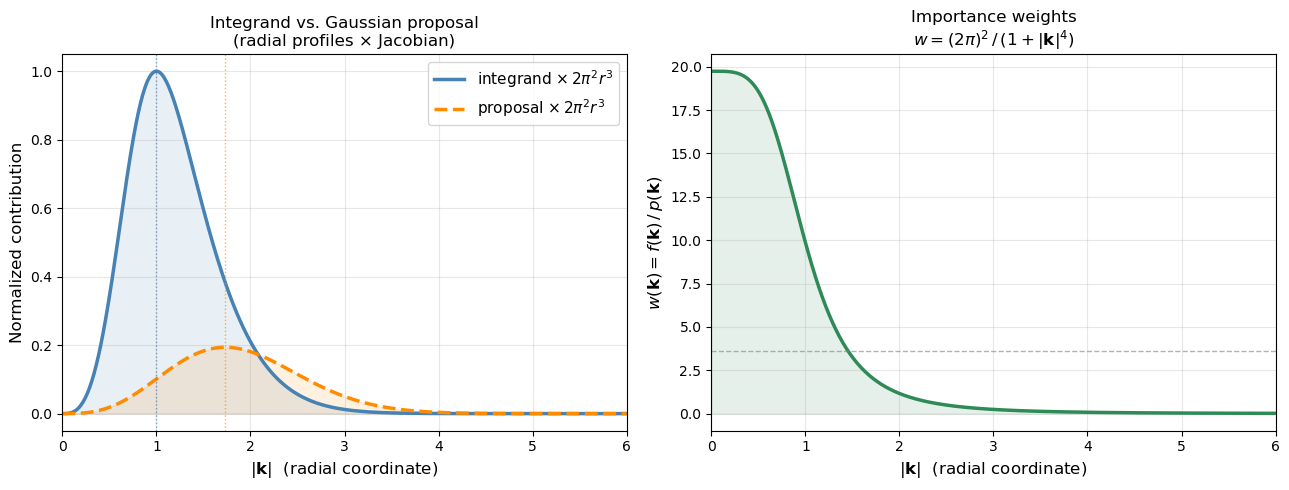

Plot saved.

N = 20000, over 200 trials:
  Uniform MC   — mean: 6.6028,  std: 1.3756
  Importance   — mean: 6.6449,  std: 0.0578
  Exact              : 6.6392
  Variance reduction : 24x


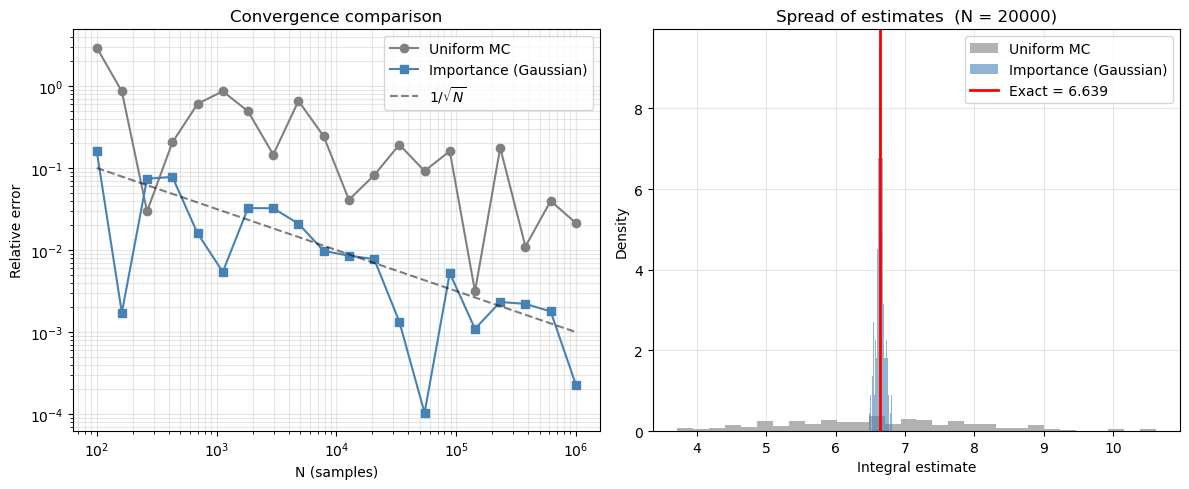

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

# ── Exact benchmark via 1D radial integration ─────────────────────────────────
# In 4D hyperspherical coords: d^4k = 2π² r³ dr
def radial_integrand(r):
    return 2 * np.pi**2 * r**3 * np.exp(-r**2 / 2) / (1 + r**4)

exact, _ = integrate.quad(radial_integrand, 0, np.inf)
print(f"Exact (numerical): {exact:.6f}")

# ── Integrand and proposal ────────────────────────────────────────────────────
def f(k):
    """Target integrand: exp(-|k|²/2) / (1 + |k|^4)"""
    k2 = np.sum(k**2, axis=-1)
    return np.exp(-k2 / 2) / (1 + k2**2)

def proposal_logp(k):
    """Log-density of isotropic unit Gaussian in 4D"""
    k2 = np.sum(k**2, axis=-1)
    return -0.5 * k2 - 4 * np.log(np.sqrt(2 * np.pi))

# ── Visualize integrand, proposal, and importance weights ─────────────────────
# Everything depends only on |k| = r, so we plot radial profiles
# multiplied by the 4D Jacobian 2π²r³ to show the actual contribution
# to the integral at each radius.

r = np.linspace(0, 6, 500)
jacobian = 2 * np.pi**2 * r**3                       # 4D hyperspherical Jacobian

f_of_r          = np.exp(-r**2/2) / (1 + r**4)       # integrand at |k|=r
proposal_of_r   = np.exp(-r**2/2) / (2*np.pi**2)     # p(k) at |k|=r  [=(2π)^-2 e^{-r²/2}]
weights_of_r    = f_of_r / proposal_of_r              # importance weight = (2π)² / (1+r^4)

integrand_contribution = jacobian * f_of_r            # what gets integrated under f
proposal_contribution  = jacobian * proposal_of_r     # what gets integrated under p

# Normalize for visual overlay
norm = np.max(integrand_contribution)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: integrand vs proposal (radial contributions)
ax = axes[0]
ax.plot(r, integrand_contribution / norm, color='steelblue', lw=2.5,
        label=r'integrand $\times\, 2\pi^2 r^3$')
ax.plot(r, proposal_contribution  / norm, color='darkorange', lw=2.5, ls='--',
        label=r'proposal $\times\, 2\pi^2 r^3$')
ax.fill_between(r, integrand_contribution / norm, alpha=0.12, color='steelblue')
ax.fill_between(r, proposal_contribution  / norm, alpha=0.12, color='darkorange')
ax.axvline(r[np.argmax(integrand_contribution)], color='steelblue',
           lw=1, ls=':', alpha=0.7)
ax.axvline(r[np.argmax(proposal_contribution)],  color='darkorange',
           lw=1, ls=':', alpha=0.7)
ax.set_xlabel(r'$|\mathbf{k}|$  (radial coordinate)', fontsize=12)
ax.set_ylabel('Normalized contribution', fontsize=12)
ax.set_title('Integrand vs. Gaussian proposal\n(radial profiles × Jacobian)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 6)

# Right panel: importance weights w(r) = f(r)/p(r) = (2π)² / (1 + r^4)
ax = axes[1]
ax.plot(r, weights_of_r, color='seagreen', lw=2.5)
ax.fill_between(r, weights_of_r, alpha=0.12, color='seagreen')
ax.axhline(np.mean(weights_of_r[r > 0]), color='gray', lw=1, ls='--', alpha=0.6)
ax.set_xlabel(r'$|\mathbf{k}|$  (radial coordinate)', fontsize=12)
ax.set_ylabel(r'$w(\mathbf{k}) = f(\mathbf{k})\,/\,p(\mathbf{k})$', fontsize=12)
ax.set_title('Importance weights\n' + r'$w = (2\pi)^2\,/\,(1 + |\mathbf{k}|^4)$',
             fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 6)

plt.tight_layout()
plt.savefig('integrand_proposal.png', dpi=130)
plt.show()
print("Plot saved.")

# ── Monte Carlo estimators ────────────────────────────────────────────────────
def mc_uniform(N, L=6.0, rng=None):
    """Uniform MC over hypercube [-L,L]^4"""
    if rng is None: rng = np.random.default_rng()
    k = rng.uniform(-L, L, size=(N, 4))
    return (2 * L)**4 * np.mean(f(k))

def mc_importance(N, rng=None):
    """Importance sampling with isotropic Gaussian proposal"""
    if rng is None: rng = np.random.default_rng()
    k = rng.normal(0, 1, size=(N, 4))
    weights = f(k) / np.exp(proposal_logp(k))
    return np.mean(weights)

# ── Convergence study ─────────────────────────────────────────────────────────
rng = np.random.default_rng(42)
Ns = np.logspace(2, 6, 20, dtype=int)

errors_uniform    = [abs(mc_uniform(N, rng=rng)    - exact) / exact for N in Ns]
errors_importance = [abs(mc_importance(N, rng=rng) - exact) / exact for N in Ns]

# ── Variance comparison ───────────────────────────────────────────────────────
N_trial, n_repeats = 20_000, 200
rng2 = np.random.default_rng(0)
uni_estimates = [mc_uniform(N_trial,    rng=rng2) for _ in range(n_repeats)]
imp_estimates = [mc_importance(N_trial, rng=rng2) for _ in range(n_repeats)]

print(f"\nN = {N_trial}, over {n_repeats} trials:")
print(f"  Uniform MC   — mean: {np.mean(uni_estimates):.4f},  std: {np.std(uni_estimates):.4f}")
print(f"  Importance   — mean: {np.mean(imp_estimates):.4f},  std: {np.std(imp_estimates):.4f}")
print(f"  Exact              : {exact:.4f}")
print(f"  Variance reduction : {np.std(uni_estimates)/np.std(imp_estimates):.0f}x")

# ── Convergence and spread plots ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].loglog(Ns, errors_uniform,    'o-', color='gray',      label='Uniform MC')
axes[0].loglog(Ns, errors_importance, 's-', color='steelblue', label='Importance (Gaussian)')
axes[0].loglog(Ns, 1 / np.sqrt(Ns),  'k--', alpha=0.5,        label=r'$1/\sqrt{N}$')
axes[0].set_xlabel('N (samples)')
axes[0].set_ylabel('Relative error')
axes[0].set_title('Convergence comparison')
axes[0].legend(); axes[0].grid(True, which='both', alpha=0.3)

axes[1].hist(uni_estimates, bins=30, alpha=0.6, density=True, color='gray',
             label='Uniform MC')
axes[1].hist(imp_estimates, bins=30, alpha=0.6, density=True, color='steelblue',
             label='Importance (Gaussian)')
axes[1].axvline(exact, color='red', lw=2, label=f'Exact = {exact:.3f}')
axes[1].set_xlabel('Integral estimate')
axes[1].set_ylabel('Density')
axes[1].set_title(f'Spread of estimates  (N = {N_trial})')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# In-Class Activity: Importance Sampling and the Variational Monte Carlo Estimate of $\langle \hat{H} \rangle$

## Background

In the previous activity you used Metropolis sampling to draw from the QHO ground-state density. Here you'll compute an expectation value as an *integral* and see directly why the choice of sampling distribution matters.

### The trial wavefunction

Instead of the exact ground state, we use a **trial wavefunction** with a free parameter $\alpha$:

$$\psi_\alpha(x) = \left(\frac{\alpha}{\pi}\right)^{1/4} e^{-\alpha x^2/2}$$

The prefactor normalizes it: $\int |\psi_\alpha|^2\,dx = 1$ for all $\alpha > 0$. Setting $\alpha = 1$ recovers the exact ground state. Any other $\alpha$ gives a valid but non-optimal trial state.

### The local energy

Apply $\hat{H} = -\frac{1}{2}\frac{d^2}{dx^2} + \frac{1}{2}x^2$ to $\psi_\alpha$ and divide:

$$E_\text{loc}(x;\alpha) = \frac{\hat{H}\psi_\alpha}{\psi_\alpha} = \frac{\alpha}{2} + \frac{1-\alpha^2}{2}\,x^2$$

Unlike the exact ground state where $E_\text{loc} = \frac{1}{2}$ everywhere, here $E_\text{loc}$ **varies with $x$** whenever $\alpha \neq 1$. This is what makes the sampling problem non-trivial.

### The expectation value

The energy estimate for the trial state is:

$$\langle \hat{H} \rangle_\alpha = \int_{-\infty}^{\infty} E_\text{loc}(x;\alpha)\, |\psi_\alpha(x)|^2\, dx$$

This has an exact analytical result (you will derive it in Part 1):

$$\langle \hat{H} \rangle_\alpha = \frac{\alpha^2 + 1}{4\alpha}$$

The variational principle guarantees $\langle \hat{H} \rangle_\alpha \geq E_0 = \frac{1}{2}$, with equality only at $\alpha = 1$. We will use $\alpha = 0.6$ throughout, giving $\langle \hat{H} \rangle_{0.6} = 17/30 \approx 0.5\overline{6}$.

### Key idea: importance sampling

We want to compute $I = \int f(x)\,dx$ where $f(x) = E_\text{loc}(x)\,|\psi_\alpha(x)|^2$. Importance sampling rewrites this as an expectation under a proposal $P(x)$:

$$I = \int \frac{f(x)}{P(x)}\,P(x)\,dx \approx \frac{1}{N}\sum_{i=1}^N \frac{f(x_i)}{P(x_i)}, \qquad x_i \sim P$$

The estimator is unbiased for any $P > 0$ where $f \neq 0$, but its variance is minimized when $P \propto |f|$.

## Part 1: Derive the Exact Result and Define Core Functions

**By hand:** evaluate $\langle \hat{H} \rangle_\alpha = \int E_\text{loc}(x)\,|\psi_\alpha|^2\,dx$ using the standard Gaussian integrals
$$\int_{-\infty}^\infty e^{-\alpha x^2}\,dx = \sqrt{\frac{\pi}{\alpha}}, \qquad \int_{-\infty}^\infty x^2 e^{-\alpha x^2}\,dx = \frac{1}{2\alpha}\sqrt{\frac{\pi}{\alpha}}$$
and confirm the result $\langle \hat{H} \rangle_\alpha = (\alpha^2+1)/4\alpha$. At what $\alpha$ is this minimized, and what is the minimum value?

Then implement the three building blocks below and plot the integrand. The plot should show you immediately why the choice of sampling distribution matters.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 0.6    # trial parameter — fixed throughout the exercise

def E_loc(x):
    """
    Local energy for trial wavefunction psi_alpha.
    E_loc(x) = alpha/2 + (1 - alpha^2)/2 * x^2

    Hint: apply H = -1/2 d^2/dx^2 + 1/2 x^2 to psi_alpha and divide by psi_alpha.
    """
    # --- YOUR CODE HERE ---
    pass

def psi_sq(x):
    """
    Normalized probability density |psi_alpha(x)|^2 = sqrt(alpha/pi) exp(-alpha x^2).
    Verify: integral over all x equals 1.
    """
    # --- YOUR CODE HERE ---
    pass

def H_exact():
    """Analytic expectation value: <H>_alpha = (alpha^2 + 1) / (4*alpha)."""
    # --- YOUR CODE HERE ---
    pass

# Plot the integrand f(x) = E_loc(x) * psi_sq(x) alongside psi_sq(x)
# and E_loc(x) on its own. What do you notice about E_loc?
x_plot = np.linspace(-4, 4, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# --- YOUR PLOT CODE HERE ---
plt.tight_layout()
plt.show()

print(f"alpha = {alpha}")
print(f"Exact <H> = {H_exact():.6f}")
print(f"True E0   = 0.5  (<H> >= E0 by variational principle)")

## Part 2: Uniform Monte Carlo and the $L$-Tradeoff

Estimate $\langle \hat{H}\rangle_\alpha$ by sampling $x_i$ uniformly on $[-L, L]$:

$$\langle \hat{H}\rangle_\alpha \approx 2L \cdot \frac{1}{N}\sum_{i=1}^N E_\text{loc}(x_i)\,|\psi_\alpha(x_i)|^2$$

Because $|\psi_\alpha|^2$ is already normalized, this direct average is correct — no ratio estimator needed.

Implement `mc_uniform` and investigate how the choice of $L$ affects both the **bias** and the **variance** of the estimate. For each $L \in \{2, 3, 4, 6, 8, 12, 20\}$, run $M = 500$ independent trials with $N = 5000$ and record the mean and standard deviation of the resulting estimates.

Produce a table and a plot showing both bias and standard deviation vs $L$.

**Questions to answer:**
- What tradeoff do you observe as $L$ increases?
- Is there a principled way to choose $L$, or must you tune it empirically?
- What does this tell you about the limitations of uniform MC for this type of integral?

In [ ]:
def mc_uniform(N, L, rng=None):
    """
    Estimate <H> by uniform MC on [-L, L].
    Estimator: (2L) * mean(E_loc(x) * psi_sq(x))

    Parameters
    ----------
    N   : int   — number of samples
    L   : float — half-width of sampling interval
    rng : numpy Generator (optional)

    Returns
    -------
    estimate : float
    x        : np.ndarray — the sampled x values
    """
    if rng is None:
        rng = np.random.default_rng()
    # --- YOUR CODE HERE ---
    pass

N_var  = 5_000
n_rep  = 500
L_vals = [2, 3, 4, 6, 8, 12, 20]

# For each L, run n_rep independent trials and record mean and std
# Print a table and produce plots of bias and std vs L
# --- YOUR CODE HERE ---

## Part 3: Importance Sampling with the Natural Proposal

Choose the proposal $P(x) = |\psi_\alpha(x)|^2 = \sqrt{\alpha/\pi}\, e^{-\alpha x^2}$, which concentrates samples exactly where the integrand is large. The IS estimator is:

$$\langle \hat{H}\rangle_\alpha \approx \frac{1}{N}\sum_{i=1}^N \frac{E_\text{loc}(x_i)\,|\psi_\alpha(x_i)|^2}{P(x_i)}, \qquad x_i \sim P$$

Work out what the IS weights $|\psi_\alpha|^2 / P(x)$ simplify to. What does this mean for the estimator?

**Before coding:** $P(x) = \sqrt{\alpha/\pi}\,e^{-\alpha x^2}$ is a Gaussian — identify $\sigma$ correctly. It is **not** $\sigma = 1$. Getting this wrong gives a biased answer.

Implement `mc_importance_good` and verify that it converges to `H_exact()` for all $N \in \{10^3, 10^4, 10^5, 10^6\}$. Note that there is no $L$ to choose.

In [ ]:
# Hint: match sqrt(alpha/pi) exp(-alpha x^2) to a N(0, sigma) PDF
#       to identify sigma before you write any sampling code.
sigma_good = None  # --- FILL IN ---

def mc_importance_good(N, rng=None):
    """
    Estimate <H> by IS with proposal P(x) = |psi_alpha(x)|^2.

    Parameters
    ----------
    N   : int
    rng : numpy Generator (optional)

    Returns
    -------
    estimate : float
    x        : np.ndarray — the sampled x values
    """
    if rng is None:
        rng = np.random.default_rng()
    # --- YOUR CODE HERE ---
    # 1. Draw x ~ N(0, sigma_good)
    # 2. Write out the IS weights explicitly before simplifying
    # 3. Return the estimate
    pass

# Convergence check — should give H_exact() for all N
rng = np.random.default_rng(42)
for N in [10**k for k in range(3, 7)]:
    est, _ = mc_importance_good(N, rng)
    print(f"N={N:>8d}:  estimate={est:.6f}  error={abs(est - H_exact()):.6f}")
print(f"Exact:           {H_exact():.6f}")

## Part 4: Variance Comparison

Use $L = 4$ for uniform MC (approximately the sweet spot from Part 2) and compare against the good IS proposal. Run both estimators $M = 500$ times with $N = 5000$ samples each.

1. Plot histograms of the two distributions of estimates on the same axes.
2. Print the mean, standard deviation, and bias for each method.
3. Report the **variance reduction factor** $\sigma_\text{uniform} / \sigma_\text{IS}$.

**Discussion:** Why does IS have lower variance here? The IS variance is $\text{Var}_P(E_\text{loc})/N$. What is the analogous expression for uniform MC, and which quantity is larger?

In [ ]:
N_var = 5_000
n_rep = 500
L_use = 4.0

rng = np.random.default_rng(0)
uni_ests  = np.array([mc_uniform(N_var, L_use, rng)[0] for _ in range(n_rep)])
good_ests = np.array([mc_importance_good(N_var, rng)[0] for _ in range(n_rep)])

# --- YOUR CODE HERE ---
# Print the comparison table and plot histograms